In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('/content/cities_weather_maharashtra.csv')
data

,date,tavg,tmin,tmax,prcp,wspd,pres,tsun,city
0,2020-01-01 00:00:00,21.4,13.7,29.1,1.0,NaN,1014.5,NaN,Achalpur
1,2020-02-01 00:00:00,24.3,15.8,32.7,0.0,NaN,1013.9,NaN,Achalpur
2,2020-03-01 00:00:00,27.9,19.7,36.2,18.0,NaN,1010.1,NaN,Achalpur
3,2020-04-01 00:00:00,33.2,24.6,41.8,2.0,NaN,1006.3,NaN,Achalpur
4,2020-05-01 00:00:00,36.1,28.1,44.0,3.0,NaN,1002.8,NaN,Achalpur
...,...,...,...,...,...,...,...,...,...
2587,2025-08-01 00:00:00,25.8,23.4,29.6,370.0,NaN,1004.7,NaN,Yavatmal
2588,2025-09-01 00:00:00,25.4,22.9,29.2,266.7,NaN,1006.0,NaN,Yavatmal
2589,2025-10-01 00:00:00,25.6,22.0,30.0,84.9,NaN,1009.8,NaN,Yavatmal
2590,2025-11-01 00:00:00,21.7,16.7,27.2,3.3,NaN,1014.7,NaN,Yavatmal


In [ ]:
#1. Find the shape of the dataset

In [ ]:
data.shape

(2592, 9)

In [ ]:
#2. Check data types of each column

In [ ]:
data.dtypes

,0
date,object
tavg,float64
tmin,float64
tmax,float64
prcp,float64
wspd,float64
pres,float64
tsun,float64
city,object


In [ ]:
data['date']=data['date'].astype('datetime64[ns]')

In [ ]:
data=data.rename(columns={'tavg':'avg'})

In [ ]:
data=data.rename(columns={'tmin':'min'})
data=data.rename(columns={'tsun':'sun'})

In [ ]:
data

,date,avg,min,tmax,prcp,wspd,pres,sun,city
0,2020-01-01,21.4,13.7,29.1,1.0,NaN,1014.5,NaN,Achalpur
1,2020-02-01,24.3,15.8,32.7,0.0,NaN,1013.9,NaN,Achalpur
2,2020-03-01,27.9,19.7,36.2,18.0,NaN,1010.1,NaN,Achalpur
3,2020-04-01,33.2,24.6,41.8,2.0,NaN,1006.3,NaN,Achalpur
4,2020-05-01,36.1,28.1,44.0,3.0,NaN,1002.8,NaN,Achalpur
...,...,...,...,...,...,...,...,...,...
2587,2025-08-01,25.8,23.4,29.6,370.0,NaN,1004.7,NaN,Yavatmal
2588,2025-09-01,25.4,22.9,29.2,266.7,NaN,1006.0,NaN,Yavatmal
2589,2025-10-01,25.6,22.0,30.0,84.9,NaN,1009.8,NaN,Yavatmal
2590,2025-11-01,21.7,16.7,27.2,3.3,NaN,1014.7,NaN,Yavatmal


In [ ]:
data['date'].min()

Timestamp('2020-01-01 00:00:00')

In [ ]:
data['date'].idxmax()

71

In [ ]:
data
#3. Count missing values in each column

,date,avg,min,tmax,prcp,wspd,pres,sun,city
0,2020-01-01,21.4,13.7,29.1,1.0,NaN,1014.5,NaN,Achalpur
1,2020-02-01,24.3,15.8,32.7,0.0,NaN,1013.9,NaN,Achalpur
2,2020-03-01,27.9,19.7,36.2,18.0,NaN,1010.1,NaN,Achalpur
3,2020-04-01,33.2,24.6,41.8,2.0,NaN,1006.3,NaN,Achalpur
4,2020-05-01,36.1,28.1,44.0,3.0,NaN,1002.8,NaN,Achalpur
...,...,...,...,...,...,...,...,...,...
2587,2025-08-01,25.8,23.4,29.6,370.0,NaN,1004.7,NaN,Yavatmal
2588,2025-09-01,25.4,22.9,29.2,266.7,NaN,1006.0,NaN,Yavatmal
2589,2025-10-01,25.6,22.0,30.0,84.9,NaN,1009.8,NaN,Yavatmal
2590,2025-11-01,21.7,16.7,27.2,3.3,NaN,1014.7,NaN,Yavatmal


In [ ]:
data['avg'].isna().sum()

np.int64(250)

In [ ]:
data=pd.DataFrame(data)

In [ ]:
data['avg']=data['avg'].fillna(data['avg'].mean())

In [ ]:
data['avg'].isna().sum()

np.int64(0)

In [ ]:
data['min'].isna().sum()

np.int64(252)

In [ ]:
data.groupby('city')['min'].mean()

,min
city,
Achalpur,21.334722
Ahmednagar,19.796491
Akola,21.475000
Amravati,21.334722
Aurangabad,20.033898
Badlapur,21.475000
Barshi,21.738983
Beed,20.579661
Bhiwandi,24.312500


In [ ]:
data['avg']=data['avg'].fillna(data.groupby('city')['avg'].transform('mean'))

In [ ]:
data.isna().sum()

,0
date,0
avg,0
min,252
tmax,273
prcp,322
wspd,2592
pres,278
sun,1666
city,0


In [ ]:
data=data.fillna(data.groupby('city').transform(np.mean))

/tmp/ipykernel_10650/626288871.py:1: FutureWarning: The provided callable <function mean at 0x7b7d38b21940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data=data.fillna(data.groupby('city').transform(np.mean))


In [ ]:
data.isna().sum()

,0
date,0
avg,0
min,0
tmax,0
prcp,0
wspd,2592
pres,0
sun,1656
city,0


In [ ]:
data['sun']

,sun
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2587,NaN
2588,NaN
2589,NaN
2590,NaN


In [ ]:
data['sun'].isna().sum()

np.int64(1656)

In [ ]:
data['sun'].count()

np.int64(936)

In [ ]:
data['sun'].sum()

np.float64(10117064.788732393)

In [ ]:
data['sun'].mean()

np.float64(10808.829902491872)

In [ ]:
data['sun']=data['sun'].fillna(data.groupby('city')['sun'].transform(np.mean))

/tmp/ipykernel_10650/2950233005.py:1: FutureWarning: The provided callable <function mean at 0x7b7d38b21940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data['sun']=data['sun'].fillna(data.groupby('city')['sun'].transform(np.mean))


In [ ]:
data['sun'].isna().sum()

np.int64(1656)

In [ ]:
data['sun'].fillna(0, inplace=True)

/tmp/ipykernel_10650/2139813451.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['sun'].fillna(0, inplace=True)


In [ ]:
data


,date,avg,min,tmax,prcp,wspd,pres,sun,city
0,2020-01-01,21.4,13.7,29.1,1.0,NaN,1014.5,0.0,Achalpur
1,2020-02-01,24.3,15.8,32.7,0.0,NaN,1013.9,0.0,Achalpur
2,2020-03-01,27.9,19.7,36.2,18.0,NaN,1010.1,0.0,Achalpur
3,2020-04-01,33.2,24.6,41.8,2.0,NaN,1006.3,0.0,Achalpur
4,2020-05-01,36.1,28.1,44.0,3.0,NaN,1002.8,0.0,Achalpur
...,...,...,...,...,...,...,...,...,...
2587,2025-08-01,25.8,23.4,29.6,370.0,NaN,1004.7,0.0,Yavatmal
2588,2025-09-01,25.4,22.9,29.2,266.7,NaN,1006.0,0.0,Yavatmal
2589,2025-10-01,25.6,22.0,30.0,84.9,NaN,1009.8,0.0,Yavatmal
2590,2025-11-01,21.7,16.7,27.2,3.3,NaN,1014.7,0.0,Yavatmal


In [ ]:
data.idxmax()

/tmp/ipykernel_10650/4258945864.py:1: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  data.idxmax()


,0
date,71.0
avg,172.0
min,172.0
tmax,4.0
prcp,618.0
wspd,NaN
pres,1319.0
sun,1300.0
city,2520.0


In [ ]:
data.idxmin()

/tmp/ipykernel_10650/2256666150.py:1: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  data.idxmin()


,0
date,0.0
avg,1536.0
min,1943.0
tmax,2544.0
prcp,1.0
wspd,NaN
pres,198.0
sun,0.0
city,0.0


In [ ]:
data.describe()

,date,avg,min,tmax,prcp,wspd,pres,sun
count,2592,2592.000000,2592.000000,2592.000000,2592.000000,0.0,2592.000000,2592.000000
mean,2022-12-16 06:40:00,26.633689,21.365318,32.373897,124.226019,NaN,1009.041806,3903.188576
min,2020-01-01 00:00:00,18.400000,10.100000,25.400000,0.000000,NaN,998.700000,0.000000
25%,2021-06-23 12:00:00,24.600000,19.100000,29.900000,1.000000,NaN,1005.900000,0.000000
50%,2022-12-16 12:00:00,26.633689,21.738983,31.713559,59.000000,NaN,1009.300000,0.000000
75%,2024-06-08 12:00:00,28.500000,24.100000,34.000000,156.325000,NaN,1012.300000,8580.000000
max,2025-12-01 00:00:00,36.500000,29.800000,44.000000,1768.900000,NaN,1016.100000,18900.000000
std,NaN,3.116617,3.582211,3.471946,206.559907,NaN,3.808269,5730.213700


In [ ]:
data['date']

,date
0,2020-01-01
1,2020-02-01
2,2020-03-01
3,2020-04-01
4,2020-05-01
...,...
2587,2025-08-01
2588,2025-09-01
2589,2025-10-01
2590,2025-11-01


In [ ]:
data=data.drop(data[data['city']=='Ichalkaranji'].index)

In [ ]:
data[data['city']=='Ichalkaranji']

,date,avg,min,tmax,prcp,wspd,pres,sun,city


In [ ]:
data['city'].unique()

array(['Achalpur', 'Ahmednagar', 'Akola', 'Amravati', 'Aurangabad',
       'Badlapur', 'Barshi', 'Beed', 'Bhiwandi', 'Bhusawal', 'Chandrapur',
       'Dhule', 'Ichalkaranji', 'Jalgaon', 'Kolhapur', 'Latur',
       'Malegaon', 'Mumbai', 'Nagpur', 'Nanded', 'Nandurbar', 'Nashik',
       'Navi Mumbai', 'Osmanabad', 'Panvel', 'Parbhani',
       'Pimpri Chinchwad', 'Pune', 'Sangli', 'Satara', 'Solapur', 'Thane',
       'Ulhasnagar', 'Vasai Virar', 'Wardha', 'Yavatmal'], dtype=object)

<Axes: xlabel='city'>

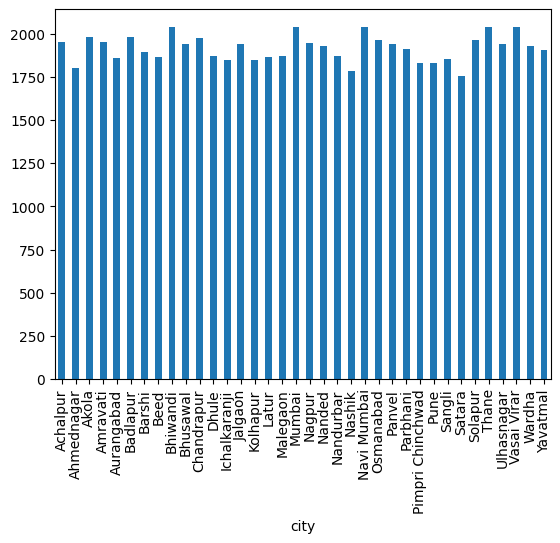

In [ ]:
data.groupby('city')['avg'].sum().plot(kind='bar')

In [ ]:
data=data.rename(columns={'tmax':'max'})


In [ ]:
data

,date,avg,min,max,prcp,wspd,pres,sun,city
0,2020-01-01,21.4,13.7,29.1,1.0,NaN,1014.5,0.0,Achalpur
1,2020-02-01,24.3,15.8,32.7,0.0,NaN,1013.9,0.0,Achalpur
2,2020-03-01,27.9,19.7,36.2,18.0,NaN,1010.1,0.0,Achalpur
3,2020-04-01,33.2,24.6,41.8,2.0,NaN,1006.3,0.0,Achalpur
4,2020-05-01,36.1,28.1,44.0,3.0,NaN,1002.8,0.0,Achalpur
...,...,...,...,...,...,...,...,...,...
2587,2025-08-01,25.8,23.4,29.6,370.0,NaN,1004.7,0.0,Yavatmal
2588,2025-09-01,25.4,22.9,29.2,266.7,NaN,1006.0,0.0,Yavatmal
2589,2025-10-01,25.6,22.0,30.0,84.9,NaN,1009.8,0.0,Yavatmal
2590,2025-11-01,21.7,16.7,27.2,3.3,NaN,1014.7,0.0,Yavatmal
